# Burn Depth Classification Using Convolutional Neural Networks
---
SOFIA DI LUCIA

**Introduction**

Correct assessment of burn depth is a fundamental step in the clinical management of burn injuries, as it directly affects treatment decisions and patient outcomes. In particular, the distinction between superficial burns and deeper injuries is crucial for determining whether surgical intervention, such as skin grafting, is required. However, accurate burn depth evaluation strongly depends on the visual experience of specialized clinicians and is therefore subject to variability and limited availability of expertise. Automated analysis of burn images has the potential to reduce subjectivity, improve early treatment decisions, and limit unnecessary patient transfers.

The present work is inspired by the study *"Segmentation and classification of burn images by color and texture information”*, in which color and texture descriptors extracted from segmented burn regions are used as inputs to a neural network classifier.

While the original approach relies on handcrafted feature extraction and a Fuzzy-ARTMAP neural network, in this notebook we investigate burn depth classification using RGB images and convolutional neural networks. CNNs allow to learn discriminative representations directly from resized color images, potentially reducing the need for manual feature design while preserving sensitivity to color and texture patterns. Due to the limited size of the available dataset, both binary and multiclass classification settings are explored.


**Reference Work**

This work is inspired by the methodology proposed in [Begoña Acha Pinero et al., 2005](https://doi.org/10.1117/1.1921227).

# Import libraries

In [49]:
import pandas as pd
import numpy as np
import os
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt

import torch
from torchvision.transforms import v2, InterpolationMode
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [50]:
# directory to save the plots
os.makedirs("Figures", exist_ok=True)

# Data

The dataset given is articuleted into two parts:
1. `data.xlsx` file contains the labels (*Superficial dermal*, *Deep dermal*, *Full-thickness*) for each sample;
2. `dataset` folder contains the samples (images).

In [51]:
base_folder = 'Burns_BIP_US_database'
info_file = 'data.xlsx'
img_folder = 'dataset'

# define the path of the file and the folder
file_path = os.path.join(base_folder, info_file)
img_path = os.path.join(base_folder, img_folder)

## Labels

In [52]:
# read the .xlsx file
raw_df = pd.read_excel(file_path)
raw_df.head(5)

,Photo number,Burn Depth
0,1,Superficial dermal
1,2,Superficial dermal
2,3,Superficial dermal
3,4,Superficial dermal
4,5,Superficial dermal


In [53]:
# drop NA values
raw_df = raw_df.dropna().reset_index(drop=True)

In [54]:
raw_df.describe()

,Photo number
count,94.000000
mean,47.500000
std,27.279418
min,1.000000
25%,24.250000
50%,47.500000
75%,70.750000
max,94.000000


In [55]:
# important later for train-test split
raw_df['Burn Depth'].value_counts()

Burn Depth
Superficial dermal    42
Deep dermal           32
Full-thickness        20
Name: count, dtype: int64

## Importing Images

In the following function we:
- import the images (we need to distinguish between two file formats: `.bmp` and `.jpg`)
- associate each (RGB) image with the corresponding label
- create a dataframe with the most useful informations to better work on them

In [56]:
def load_images(df, img_path):
    # empty lists to collect info
    
    filenames = []
    format = []
    path = []
    W = []
    H = []
    ratio = []
    labels = []

    # for each sample (row in .xslx file)
    for _, row in df.iterrows():

        # associate the correct format
        if row['Photo number'] <= 20:
            ext = "bmp"
        else:
            ext = "jpg"
        
        file_name = f"{int(row['Photo number'])}.{ext}"
        file_path = os.path.join(img_path, file_name)

        # load the image
        img = Image.open(file_path).convert('RGB')        

        # collect info
        filenames.append(file_name)
        format.append(ext)
        path.append(file_path)
        W.append(img.width)
        H.append(img.height)
        ratio.append(img.width / img.height)
        labels.append(row['Burn Depth'])

    
    # create a dataframe
    df_images = pd.DataFrame({
        "filename": filenames,
        "format": format,
        "Path": path,
        "Width": W,
        "Height": H,
        "Aspect Ratio": ratio,
        "Label": labels
    })

    return df_images
        

In [57]:
df_images = load_images(raw_df, img_path)
df_images.head(5)

,filename,format,Path,Width,Height,Aspect Ratio,Label
0,1.bmp,bmp,Burns_BIP_US_database\dataset\1.bmp,505,418,1.208134,Superficial dermal
1,2.bmp,bmp,Burns_BIP_US_database\dataset\2.bmp,833,390,2.135897,Superficial dermal
2,3.bmp,bmp,Burns_BIP_US_database\dataset\3.bmp,366,252,1.452381,Superficial dermal
3,4.bmp,bmp,Burns_BIP_US_database\dataset\4.bmp,419,295,1.420339,Superficial dermal
4,5.bmp,bmp,Burns_BIP_US_database\dataset\5.bmp,461,233,1.978541,Superficial dermal


## Inspect data

### Labels

For each class (*Superficial dermal*, *Deep dermal*, *Full-thickness*), we calculate:
- **Absolute frequency** to know the number of samples per class
- **Relative frequency** to know if there is a class imbalance

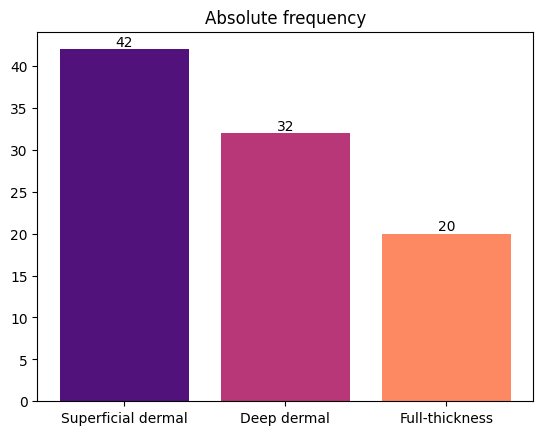

In [58]:
counts = df_images['Label'].value_counts()
colors = sns.color_palette("magma", n_colors=3)

plt.bar(
    counts.index,
    counts.values,
    color = colors
)

plt.title('Absolute frequency')
plt.xlabel('')
plt.ylabel('')
plt.bar_label(plt.gca().containers[0], fontsize=10)

plt.savefig("Figures/Absolute_Frequency.pdf", bbox_inches="tight")
plt.show()


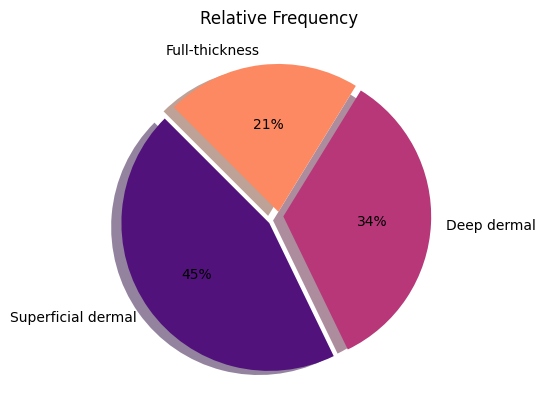

In [59]:
counts = df_images['Label'].value_counts(normalize=True)

labels = counts.index
sizes = counts.values
explode = (0.08, 0.03, 0.03)
colors = sns.color_palette("magma", n_colors=3)
fig, ax = plt.subplots()
ax.pie(
    sizes,
    explode=explode,
    labels=labels,
    autopct='%1.0f%%',
    shadow={'ox': -0.05, 'edgecolor': 'none', 'shade': 0.5},
    startangle=135,
    colors=colors
)

ax.set_title('Relative Frequency')
plt.savefig("Figures/Relative_Frequency.pdf", bbox_inches="tight")
plt.show()


We can see that the dataset is **imbalanced**: *Superficial dermal* is the most represented class ($\sim 45\%$) while *Full-thickness* is the least frequent ($\sim 21\%$), which may bias the model toward the majority class.

### Images

In the following we inspect the images' sizes.

In [60]:
ar_mode = df_images['Aspect Ratio'].mode().item()
print(f'Aspect Ratio mode: {ar_mode:.2f}')

Aspect Ratio mode: 1.11


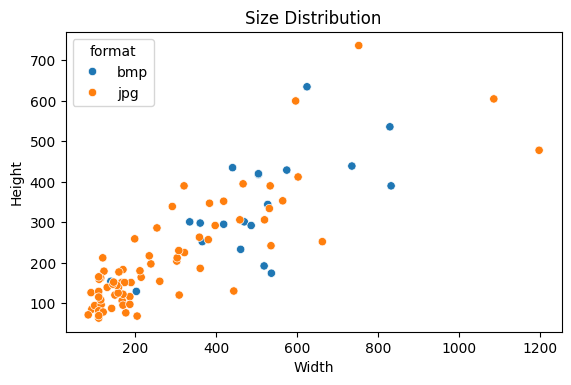

In [61]:
ax = sns.scatterplot(df_images, x="Width", y="Height", hue='format')
ax.set_title('Size Distribution')
ax.set_aspect('equal')
plt.savefig("Figures/Size_Distribution.pdf", bbox_inches="tight")
plt.show()

We can see how the sizes of the images in the dataset are distributed over a wide range, with a concentration of samples clustered around 200×200 pixels or below, indicating that a significant portion of the dataset consists of relatively small images. Also we know that they are mostly squared images.

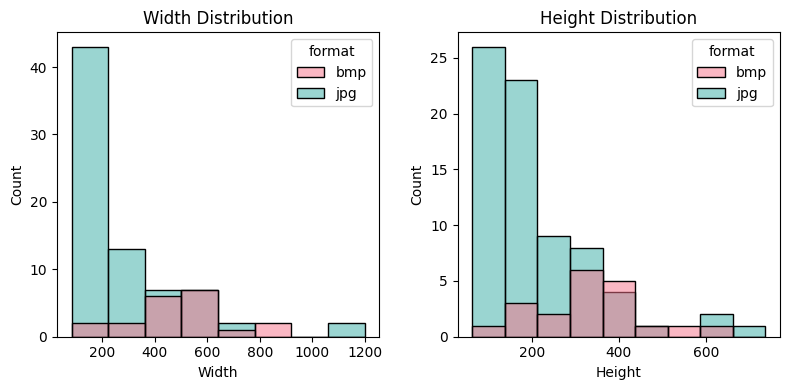

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Width
sns.histplot(df_images, x="Width", hue="format", palette='husl', ax=axes[0])
axes[0].set_title('Width Distribution')

# Height
sns.histplot(df_images, x="Height", hue="format", palette='husl', ax=axes[1])
axes[1].set_title('Height Distribution')

plt.tight_layout()
plt.savefig("Figures/Width_Height_Distr.pdf", bbox_inches="tight")
plt.show()


# Binary Classification

## Pre-processing

In [63]:
# keep only the columns of interest
df = df_images.copy()
df = df[['Path', 'Label']]
df.sample(5)

,Path,Label
66,Burns_BIP_US_database\dataset\67.jpg,Deep dermal
39,Burns_BIP_US_database\dataset\40.jpg,Full-thickness
92,Burns_BIP_US_database\dataset\93.jpg,Superficial dermal
72,Burns_BIP_US_database\dataset\73.jpg,Superficial dermal
37,Burns_BIP_US_database\dataset\38.jpg,Deep dermal


### Label Encoding

Before proceeding, we need to distinguish between the two different type of classification:

**BINARY CLASSIFICATION**:
- Class 0: *Superficial dermal*
- Class 1: *Deep dermal* + *Full-thickness*

**MULTI-CLASS CLASSIFICATION**:
- Class 0: *Superficial dermal*
- Class 1: *Deep dermal*
- Class 2: *Full-thickness*

Thus, we need two different functions to encode the categorical class label into a numerical one.

In [64]:
def binary_class(y):
    encod_map = {'Superficial dermal': 0, 'Deep dermal': 1, 'Full-thickness': 1}
    encod_lab = encod_map[y]
    return int(encod_lab) 

def multi_class(y):
    encod_map = {'Superficial dermal': 0, 'Deep dermal': 1, 'Full-thickness': 2}
    encod_lab = encod_map[y]
    return int(encod_lab)

In this section we focus on binary classification so we use the `binary_class` function to encode.

In [65]:
df['target'] = df['Label'].apply(binary_class)
df.drop(columns='Label', inplace=True)
df.sample(5)

,Path,target
39,Burns_BIP_US_database\dataset\40.jpg,1
66,Burns_BIP_US_database\dataset\67.jpg,1
9,Burns_BIP_US_database\dataset\10.bmp,1
30,Burns_BIP_US_database\dataset\31.jpg,0
53,Burns_BIP_US_database\dataset\54.jpg,0


### Train-Test Split

In [66]:
df['target'].value_counts()

target
1    52
0    42
Name: count, dtype: int64

Because we have few samples and they are not equal balanced, we need a **stratified split** to be sure to have the same distribution of classes in both test and train set.

For the split we use: $70\%$ of the data for training set, $15\%$ for validation and $15\%$ for test.

In [67]:
train, test = train_test_split(df, test_size=0.3, random_state=8, shuffle=True, stratify=df['target'])
val, test = train_test_split(test, test_size=0.5, random_state=8, shuffle=True, stratify=test['target'])

print(f'Training set size: {len(train)}')
print(val['target'].value_counts(normalize=True),'\n')
print(f'Validation set size: {len(test)}')
print(val['target'].value_counts(normalize=True), '\n')
print(f'Test set size: {len(test)}')
print(test['target'].value_counts(normalize=True))

Training set size: 65
target
1    0.571429
0    0.428571
Name: proportion, dtype: float64 

Validation set size: 15
target
1    0.571429
0    0.428571
Name: proportion, dtype: float64 

Test set size: 15
target
1    0.533333
0    0.466667
Name: proportion, dtype: float64


### Images Pre-Processing & Augmentation

As mentioned above, the images have non-uniform dimensions that vary within a quite wide range. The purpose of this part is to **standardize** them for CNN. In the following, we define the `transform` function that pursue this goal (and that will be applied later for the `DataLoader`). Furthermore, given the very small number of amples available, **augmentation** is necessary  to improve generalization but it will be applied only to the training set. 

For this reason, two distinct functions are defined, both:
- **resize** images to a fixed resolution (256x256 pixels)
- **normalize** the image values in the [-1, 1] range
- for training set also:
    - randomly **flips images horizontally** with a $20\%$ probability

In [68]:
H, W = 256, 256
mean = [0.5, 0.5, 0.5]
std = [0.5, 0.5, 0.5]

# transform to use on validation and test
transf = v2.Compose([
    v2.ToImage(),   # convert the input (PIL Image) to a torchvision Image tensor
    v2.Resize(size=(H, W), interpolation=InterpolationMode.BICUBIC, antialias=True), # BICUBIC for more detailed results than BILINEAR
    v2.ToDtype(torch.float32, scale=True),  # convert image values to -> float32 in [0, 1] range
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])     # normalize in [-1, 1] range
])

# transform to use on training
train_transf = v2.Compose([
    v2.ToImage(),
    v2.Resize(size=(H, W), interpolation=InterpolationMode.BICUBIC, antialias=True),
    v2.RandomHorizontalFlip(p=0.2), # for augmentation
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std)
])

## DataLoader

We create a custom Dataset to handle images stored in file paths with corresponding labels and to integrate the previous transform functions.

In [69]:
class CustomImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.img_labels = df['target'].values
        self.img_paths = df['Path'].values
        self.transform = transform

    # return the number of samples in our dataset
    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        path = str(self.img_paths[idx])
        image = Image.open(path).convert('RGB')     # load image from disk

        if self.transform:
            image = self.transform(image)   # apply transformation
            
        label = torch.tensor(self.img_labels[idx], dtype=torch.long)    # convert the label to torch.long (required after by CrossEntropyLoss)

        return image, label

In [70]:
dataset_train = CustomImageDataset(df=train, transform=train_transf)
dataset_test = CustomImageDataset(df=test, transform=transf)
dataset_val = CustomImageDataset(df=val, transform=transf)

We wrap the datasets in DataLoader objects to have **mini-batches of 15 samples** each.

In [71]:
batch_size = 15
trainloader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
testloader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)
valloader = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

In [72]:
images, labels = next(iter(trainloader))

print(f'Image shape: {images.shape}')
print(f'Image type: {images.dtype}\n')
print(f'Label shape: {labels.shape}')
print(f'Label type: {labels.dtype}\n')

Image shape: torch.Size([15, 3, 256, 256])
Image type: torch.float32

Label shape: torch.Size([15])
Label type: torch.int64



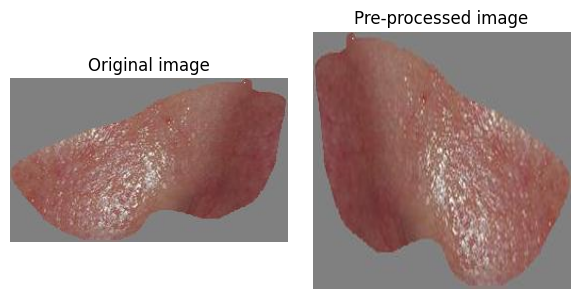

In [73]:
idx = 2

# original image
file_path = dataset_train.img_paths[idx]
img_orig = Image.open(file_path).convert('RGB')

# processed image
img_proc, label = dataset_train[idx]

mean = torch.tensor([0.5, 0.5, 0.5])
std  = torch.tensor([0.5, 0.5, 0.5])

img_proc = img_proc * std[:, None, None] + mean[:, None, None]
img_proc = img_proc.permute(1, 2, 0)
img_proc = img_proc.clamp(0, 1)

# plot
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(img_orig)
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(img_proc)
axes[1].set_title("Pre-processed image")
axes[1].axis("off")

plt.tight_layout()
plt.savefig('Figures/orig_vs_proc.pdf', bbox_inches="tight")
plt.show()


## CNN

### Architecture

The CNN architecure used for the **binary classification** is the following one:

<img src="Figures/Binary_model.png" width=700px>

In [74]:
class CNN(nn.Module):
    def __init__(self, input_size=3, out_size=2):
        super(CNN, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=input_size, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(output_size=1)
        )

        self.fc1 = nn.Linear(in_features=128, out_features=out_size)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.conv1(x)   # 3x(256x256) -> 32x(256x256) -> 32x(128x128)
        x = self.conv2(x)   # 32x(128x128) -> 64x(128x128) -> 64x(64x64)
        x = self.conv3(x)   # 64x(64x64) -> 128x(64x64) -> 128x(1x1)
        x = torch.flatten(x, 1)     # 128x(1x1) -> 128
        x = self.fc1(x)     # 128 -> 2
        return x

In [75]:
model = CNN(input_size=3, out_size=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(model)

CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): AdaptiveAvgPool2d(output_size=1)
  )
  (fc1): Linear(in_features=128, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


### Train

In the following we define two functions, `train_epoch` and `test_epoch`, to train and evaluate the model across the epochs during training. The function `test_epoch` will be also useful for the final evaluation using the test set.

In these function we track the train-validation losses and we also compute the validation accuracy, i.e. the number of correct predictions out of the total number of samples.

#### Useful Functions

In [76]:
def train_epoch(model, trainloader, optimizer, criterion, device):
    model.train()   # set train mode

    train_loss = 0  # to track one-epoch loss

    # iterate over the batches
    for (images, labels) in trainloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()       # reset the gradients

        logits = model(images)      # forward pass
        loss = criterion(logits, labels)    # compute loss
        
        loss.backward()     # backward pass
        optimizer.step()    # parameters update
        
        train_loss += loss.item()*images.size(0)    # track loss

    epoch_train_loss = train_loss/len(trainloader.dataset)      # average total loss
        
    return epoch_train_loss


In [77]:
def test_epoch(model, valloader, criterion, device):
    model.eval()    # set eval mode
    
    val_loss = 0    # to track one-epoch loss and
    correct = 0     # accuracy
    total = 0
    y_pred = []     # for confusion matrix later
    y_true = []
    
    # disable gradient computation
    with torch.no_grad():
    
        for (images, labels) in valloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            val_loss += loss.item()*images.size(0)

            # compute prediction and count the correct ones for accuracy 
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            y_pred.append(preds.cpu())
            y_true.append(labels.cpu())

    epoch_val_loss = val_loss/len(valloader.dataset)
    epoch_accuracy = correct/total      # compute accuracy

    y_pred = torch.cat(y_pred).numpy()      # numpy to plot later
    y_true = torch.cat(y_true).numpy()

    return epoch_val_loss, epoch_accuracy, y_true, y_pred

#### Training Loop

Now we iterate the training loop for `num_epochs=100`. We use **Adam optimizer** and **Cross-entropy Loss**, we also add early stopping to stop training if no improvement is observed for a `patience=5` consecutive epochs and we save the best model (the one with lowest validation loss) in `best_model_biclass.pth`.

In [78]:
# track losses over epochs
train_losses = []
val_losses = []
accuracy = []

# hyperparameters
num_epochs = 100
learn_rate = 3e-4

# loss and optimizer
optimizer = optim.AdamW(params=model.parameters(), lr=learn_rate)
criterion = nn.CrossEntropyLoss()

# enable early stopping
early_stop = True

if early_stop:
    patience = 5
    best_val_loss = 1e5
    epoch_no_improv = 0

# repeat for num_epochs times
for e in range(1, num_epochs+1):
    epoch_train_loss = train_epoch(model, trainloader, optimizer, criterion, device)
    epoch_val_loss, epoch_accuracy, y_true_val, y_pred_val = test_epoch(model, valloader, criterion, device)

    print(f'Epoch {e}/{num_epochs}:    Training Loss: {epoch_train_loss:.3f}      Validation Loss: {epoch_val_loss:.3f}     Accuracy: {epoch_accuracy*100:.2f}%')
    
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    accuracy.append(epoch_accuracy)
    
    if early_stop:
        # save the best model and count the patience
        if epoch_val_loss<best_val_loss:
            best_val_loss = epoch_val_loss
            epoch_no_improv = 0
            torch.save(model.state_dict(), 'best_model_biclass.pth')
        else:
            epoch_no_improv += 1

        if epoch_no_improv >= patience:
            print(f'No more improvement in the last {patience} epochs.')
            break

Epoch 1/100:    Training Loss: 0.688      Validation Loss: 0.673     Accuracy: 64.29%
Epoch 2/100:    Training Loss: 0.672      Validation Loss: 0.649     Accuracy: 64.29%
Epoch 3/100:    Training Loss: 0.649      Validation Loss: 0.618     Accuracy: 64.29%
Epoch 4/100:    Training Loss: 0.622      Validation Loss: 0.581     Accuracy: 64.29%
Epoch 5/100:    Training Loss: 0.589      Validation Loss: 0.546     Accuracy: 78.57%
Epoch 6/100:    Training Loss: 0.563      Validation Loss: 0.523     Accuracy: 64.29%
Epoch 7/100:    Training Loss: 0.542      Validation Loss: 0.493     Accuracy: 78.57%
Epoch 8/100:    Training Loss: 0.520      Validation Loss: 0.458     Accuracy: 85.71%
Epoch 9/100:    Training Loss: 0.500      Validation Loss: 0.424     Accuracy: 85.71%
Epoch 10/100:    Training Loss: 0.485      Validation Loss: 0.412     Accuracy: 85.71%
Epoch 11/100:    Training Loss: 0.470      Validation Loss: 0.388     Accuracy: 85.71%
Epoch 12/100:    Training Loss: 0.453      Validatio

## Results

### Losses Plot

After training, we plot the training/validation loss curves across epochs to monitor model convergence (and potential overfitting) and we print the main training hyperparameters.


Resize: (256, 256)
Batch size: 15
Learning rate: 0.0003
Optimizer: AdamW
Loss: CrossEntropyLoss
Epochs: 100



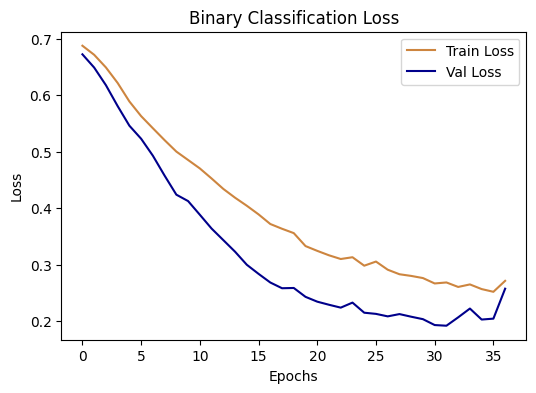

In [79]:
print(f'Resize: {(H,W)}\n'
    f'Batch size: {batch_size}\n'
    f'Learning rate: {optimizer.param_groups[0]["lr"]}\n'
    f'Optimizer: {optimizer.__class__.__name__}\n'
    f'Loss: {criterion.__class__.__name__}\n'
    f'Epochs: {num_epochs}\n'
)

fig, ax = plt.subplots(figsize=(6,4))
plt.plot(train_losses, label='Train Loss', color='peru')
plt.plot(val_losses, label='Val Loss', color='darkblue')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Binary Classification Loss')
plt.legend()
plt.savefig("Figures/Binary_Loss.pdf", bbox_inches="tight")
plt.show()

Both training and validation losses decrease consistently over epochs: the validation loss remains lower than the training loss, not indicating evident overfitting. We can say that the model converges stably, suggesting a good generalization, we can prove it using the test set.

### Test and Evaluation

We load the best model previously saved and test it to see how it performs on test data.

In [80]:
model.load_state_dict(torch.load('best_model_biclass.pth'))

test_loss, test_accuracy, y_true, y_pred = test_epoch(model, testloader, criterion, device)

print(f'Test Loss: {test_loss:.3f}')
print('Test Accuracy: {:.2f}%'.format(test_accuracy*100))

Test Loss: 0.479
Test Accuracy: 86.67%


### Confusion Matrix

Here we plot the confusion matrix to see the accuracy of our model for each class.

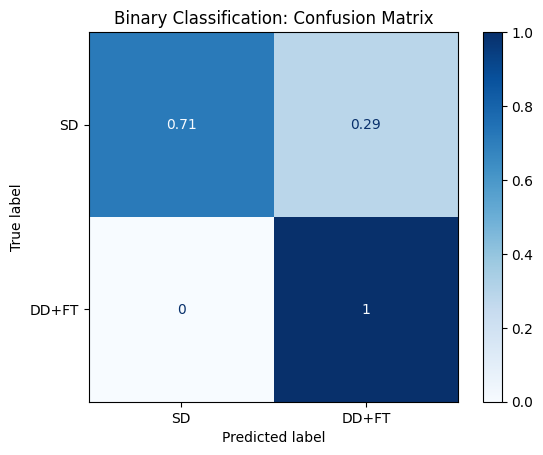

In [81]:
cm = confusion_matrix(y_true, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['SD', 'DD+FT'])
disp.plot(cmap='Blues')
plt.title('Binary Classification: Confusion Matrix')
plt.savefig("Figures/Binary_CM.pdf", bbox_inches="tight")
plt.show()

In [34]:
print(classification_report(
    y_true,
    y_pred,
    target_names=['SD', 'DD+FT']
))

              precision    recall  f1-score   support

          SD       1.00      0.57      0.73         7
       DD+FT       0.73      1.00      0.84         8

    accuracy                           0.80        15
   macro avg       0.86      0.79      0.78        15
weighted avg       0.85      0.80      0.79        15



The model correctly classified all deep dermal and full-thickness burns, while superficial dermal burns were classified with a recall of 0.57, indicating that a portion of superficial cases was misclassified as deeper burns. This behavior suggests that the model tends to overestimate burn severity rather than underestimate it.

# Multi-Class Classification

In the following we will focus on multi-class classification, i.e. we will try to distinguish between the three different classes (*Superficial dermal*, *Deep dermal*, *Full-thickness*).


## Pre-processing

### Label Encoding

In this case we will use the `multi_class` function to encode the labels.

In [35]:
df = df_images.copy()
df = df[['Path', 'Label']]
df['target'] = df['Label'].apply(multi_class)
df.drop(columns='Label', inplace=True)
df.sample(5)

,Path,target
27,Burns_BIP_US_database\dataset\28.jpg,0
88,Burns_BIP_US_database\dataset\89.jpg,0
80,Burns_BIP_US_database\dataset\81.jpg,1
77,Burns_BIP_US_database\dataset\78.jpg,1
79,Burns_BIP_US_database\dataset\80.jpg,1


### Train-Test Split

In [36]:
df['target'].value_counts()

target
0    42
1    32
2    20
Name: count, dtype: int64

As before, we have not equal balanced classes so we need a **stratified split**. The train-val-test split will be again $70\%$ - $15\%$ - $15\%$.

In [37]:
train, test = train_test_split(df, test_size=0.30, random_state=8, shuffle=True, stratify=df['target'])
val, test = train_test_split(test, test_size=0.5, random_state=8, shuffle=True, stratify=test['target'])

print(f'Training set size: {len(train)}')
print(val['target'].value_counts(normalize=True),'\n')
print(f'Validation set size: {len(test)}')
print(val['target'].value_counts(normalize=True), '\n')
print(f'Test set size: {len(test)}')
print(test['target'].value_counts(normalize=True))

Training set size: 65
target
0    0.428571
1    0.357143
2    0.214286
Name: proportion, dtype: float64 

Validation set size: 15
target
0    0.428571
1    0.357143
2    0.214286
Name: proportion, dtype: float64 

Test set size: 15
target
0    0.466667
1    0.333333
2    0.200000
Name: proportion, dtype: float64


## DataLoader

We use the previously created custom Dataset as well as the transform functions. Also here we use **mini-batches of 15 samples**.

In [38]:
dataset_train = CustomImageDataset(df=train, transform=train_transf)
dataset_test = CustomImageDataset(df=test, transform=transf)
dataset_val = CustomImageDataset(df=val, transform=transf)

In [39]:
batch_size = 15
trainloader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
testloader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)
valloader = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

In [40]:
images, labels = next(iter(trainloader))

print(f'Image shape: {images.shape}')
print(f'Image type: {images.dtype}\n')
print(f'Label shape: {labels.shape}')
print(f'Label type: {labels.dtype}\n')

Image shape: torch.Size([15, 3, 256, 256])
Image type: torch.float32

Label shape: torch.Size([15])
Label type: torch.int64



Let's visualize some samples.

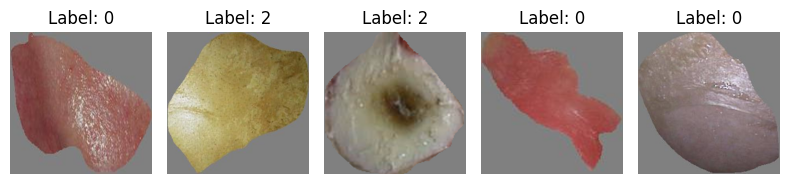

In [41]:
mean = torch.tensor([0.5, 0.5, 0.5])
std = torch.tensor([0.5, 0.5, 0.5])

dataiter = iter(trainloader) 
images, labels = next(dataiter)

fig, axes = plt.subplots(1, 5, figsize=(8, 2))

for i in range(5):
    img = images[i].cpu()
    img = img * std[:, None, None] + mean[:, None, None]
    img = img.permute(1, 2, 0)

    axes[i].imshow(img)
    axes[i].set_title(f'Label: {labels[i].item()}')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("Figures/Samples.pdf", bbox_inches="tight")
plt.show()

## CNN

### Architecture

We use the same architecture as before but of course with 3 output instead of 2:

<img src="Figures/Multi_model.png" width=700px>

In [42]:
model = CNN(input_size=3, out_size=3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(model)

CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): AdaptiveAvgPool2d(output_size=1)
  )
  (fc1): Linear(in_features=128, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


### Train

Same training loop as before using **Adam optimizer** and **Cross-entropy Loss**. 

In [43]:
train_losses = []
val_losses = []
accuracy = []

num_epochs = 100
learn_rate = 3e-4

optimizer = optim.AdamW(params=model.parameters(), lr=learn_rate)
criterion = nn.CrossEntropyLoss()

early_stop = True

if early_stop:
    patience = 5
    best_val_loss = 1e5
    epoch_no_improv = 0

for e in range(1, num_epochs+1):
    epoch_train_loss = train_epoch(model, trainloader, optimizer, criterion, device)
    epoch_val_loss, epoch_accuracy, y_true_val, y_pred_val = test_epoch(model, valloader, criterion, device)

    print(f'Epoch {e}/{num_epochs}:    Training Loss: {epoch_train_loss:.3f}      Validation Loss: {epoch_val_loss:.3f}     Accuracy: {epoch_accuracy*100:.2f}%')
    
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    accuracy.append(epoch_accuracy)
    
    if early_stop:
        if epoch_val_loss<best_val_loss:
            best_val_loss = epoch_val_loss
            epoch_no_improv = 0
            torch.save(model.state_dict(), 'best_model_multiclass.pth')
        else:
            epoch_no_improv += 1
        if epoch_no_improv >= patience:
            print(f'No more improvement in the last {patience} epochs.')
            break

Epoch 1/100:    Training Loss: 1.092      Validation Loss: 1.080     Accuracy: 57.14%
Epoch 2/100:    Training Loss: 1.078      Validation Loss: 1.066     Accuracy: 71.43%
Epoch 3/100:    Training Loss: 1.065      Validation Loss: 1.046     Accuracy: 57.14%
Epoch 4/100:    Training Loss: 1.045      Validation Loss: 1.021     Accuracy: 50.00%
Epoch 5/100:    Training Loss: 1.018      Validation Loss: 0.991     Accuracy: 57.14%
Epoch 6/100:    Training Loss: 0.991      Validation Loss: 0.957     Accuracy: 57.14%
Epoch 7/100:    Training Loss: 0.960      Validation Loss: 0.924     Accuracy: 64.29%
Epoch 8/100:    Training Loss: 0.935      Validation Loss: 0.890     Accuracy: 71.43%
Epoch 9/100:    Training Loss: 0.906      Validation Loss: 0.858     Accuracy: 71.43%
Epoch 10/100:    Training Loss: 0.879      Validation Loss: 0.821     Accuracy: 71.43%
Epoch 11/100:    Training Loss: 0.853      Validation Loss: 0.780     Accuracy: 71.43%
Epoch 12/100:    Training Loss: 0.825      Validatio

## Results

### Losses Plot

Resize: (256, 256)
Batch size: 15
Learning rate: 0.0003
Optimizer: AdamW
Loss: CrossEntropyLoss
Epochs: 100



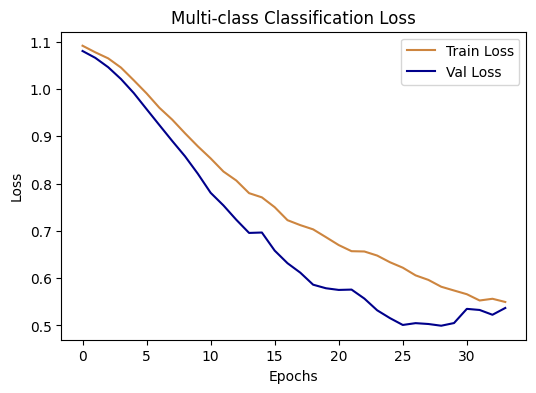

In [44]:
print(f'Resize: {(H,W)}\n'
    f'Batch size: {batch_size}\n'
    f'Learning rate: {optimizer.param_groups[0]["lr"]}\n'
    f'Optimizer: {optimizer.__class__.__name__}\n'
    f'Loss: {criterion.__class__.__name__}\n'
    f'Epochs: {num_epochs}\n'
)

fig, ax = plt.subplots(figsize=(6,4))
plt.plot(train_losses, label='Train Loss', color='peru')
plt.plot(val_losses, label='Val Loss', color='darkblue')
plt.title('Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Multi-class Classification Loss')
plt.savefig("Figures/Multiclass_Loss.pdf", bbox_inches="tight")
plt.show()

Also in this case training and validation losses show a decreasing trend, although convergence is slower and losses remain higher compared to the binary case. This behavior reflects the increased complexity of the task and the class imbalance.

### Test and Evaluation

In [45]:
model.load_state_dict(torch.load('best_model_multiclass.pth'))

test_loss, test_accuracy, y_true, y_pred = test_epoch(model, testloader, criterion, device)

print(f'Test Loss: {test_loss:.3f}')
print('Test Accuracy: {:.2f}%'.format(test_accuracy*100))

Test Loss: 0.861
Test Accuracy: 66.67%


### Confusion Matrix

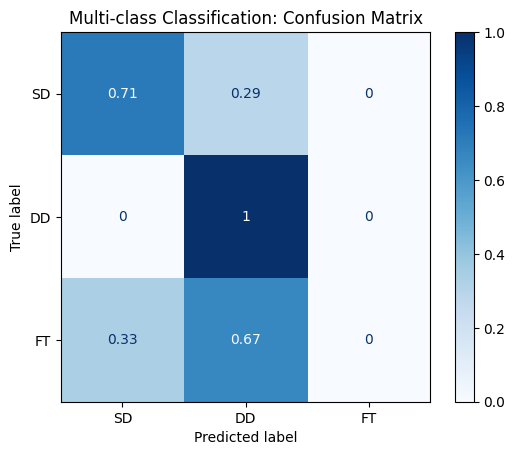

In [46]:
cm = confusion_matrix(y_true, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['SD', 'DD', 'FT'])
disp.plot(cmap='Blues')
plt.title('Multi-class Classification: Confusion Matrix')
plt.savefig("Figures/Multiclass_CM.pdf", bbox_inches="tight")
plt.show()

In [48]:
print(classification_report(
    y_true,
    y_pred,
    target_names=['SD', 'DD', 'FT'],
    zero_division=0.0
))


              precision    recall  f1-score   support

          SD       0.83      0.71      0.77         7
          DD       0.56      1.00      0.71         5
          FT       0.00      0.00      0.00         3

    accuracy                           0.67        15
   macro avg       0.46      0.57      0.49        15
weighted avg       0.57      0.67      0.60        15



Performance varies significantly across classes:
- Superficial dermal burns were classified with reasonable precision and recall
- Deep dermal burns samples are correctly identified, although with lower precision due to confusion with neighboring classes
- The model failed to correctly classify full-thickness burns and this result is mainly attributed to the very limited number of full-thickness samples available for training and testing, combined with class imbalance and visual similarity between deep dermal and full-thickness burns.

Overall, these results highlight the increased difficulty of the multi-class problem and confirm that the binary classification task is more robust in low-data scenarios.